Import Necessary Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#Other will be imported later

EDA

Load dataset

In [2]:
df = pd.read_csv(r'D:\ml learning\ChurnGuard\data\synthetic_customer_churn_100k.csv')
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


Check Shape and other information

In [3]:
print(df.shape)

(100000, 9)


In [4]:
print(df.describe())

          CustomerID            Age         Tenure  MonthlyCharges  \
count  100000.000000  100000.000000  100000.000000   100000.000000   
mean    50000.500000      49.027240      36.527090       79.974933   
std     28867.657797      18.177862      20.789552       40.491961   
min         1.000000      18.000000       1.000000       10.000000   
25%     25000.750000      33.000000      18.000000       44.720000   
50%     50000.500000      49.000000      37.000000       80.000000   
75%     75000.250000      65.000000      54.000000      115.050000   
max    100000.000000      80.000000      72.000000      150.000000   

        TotalCharges  
count  100000.000000  
mean     2926.140256  
std      2388.163672  
min      -118.430000  
25%       963.667500  
50%      2268.060000  
75%      4394.327500  
max     10831.460000  


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB
None


No null values found

Count plots for string column

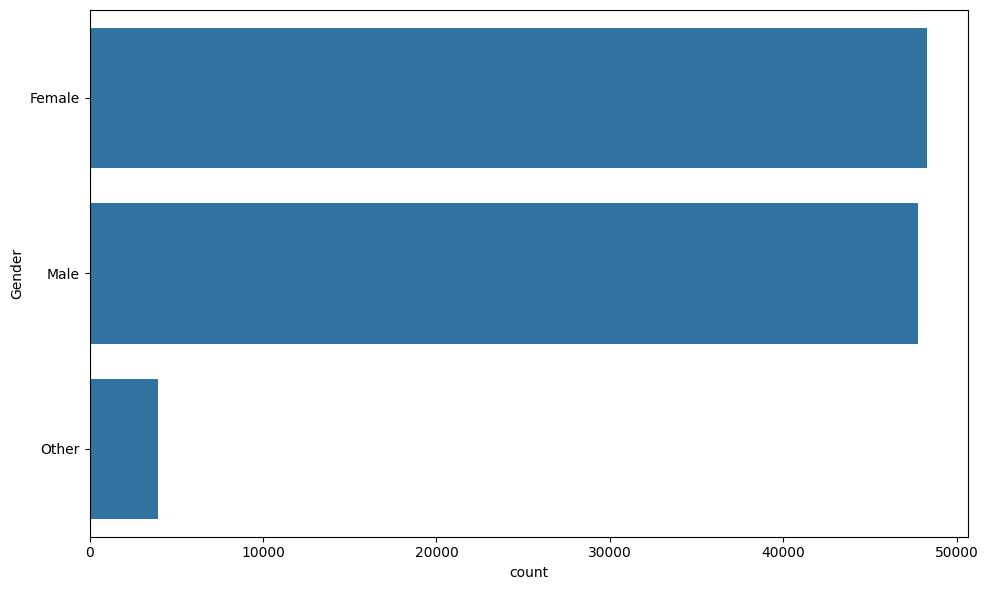

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(df['Gender'])
plt.tight_layout()
plt.show()

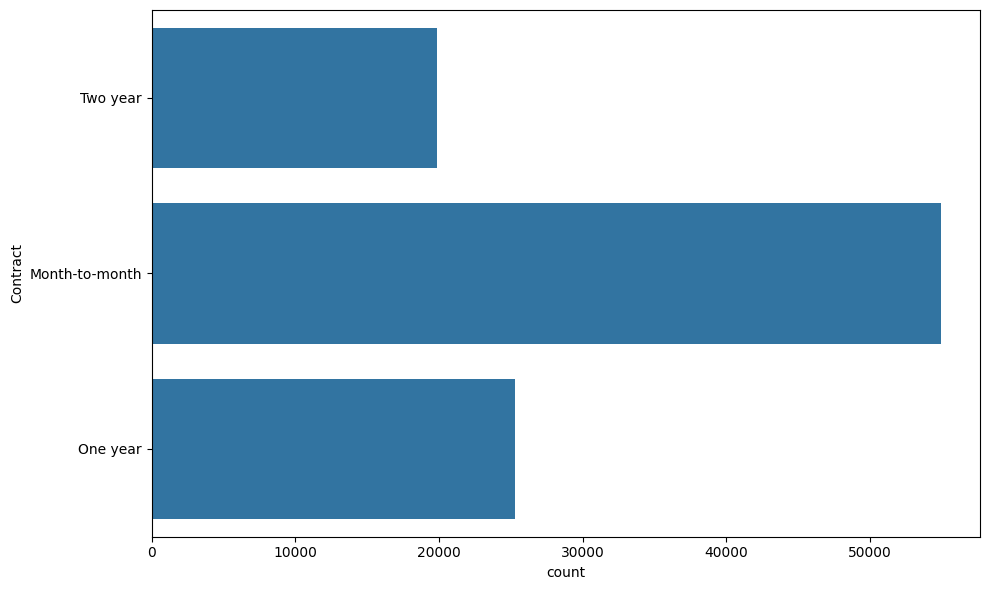

In [7]:
plt.figure(figsize=(10,6))
sns.countplot(df['Contract'])
plt.tight_layout()
plt.show()

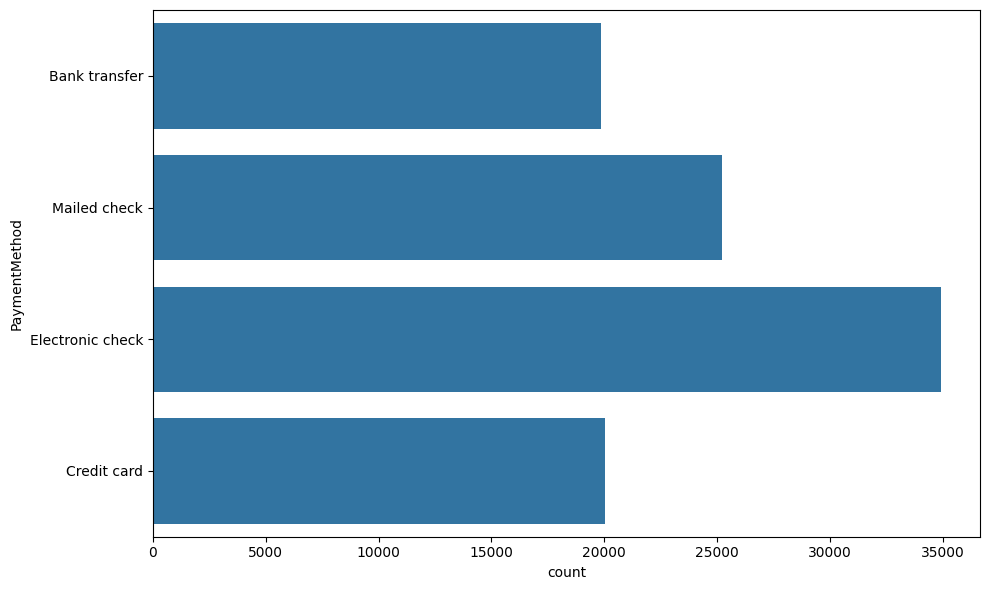

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(df['PaymentMethod'])
plt.tight_layout()
plt.show()

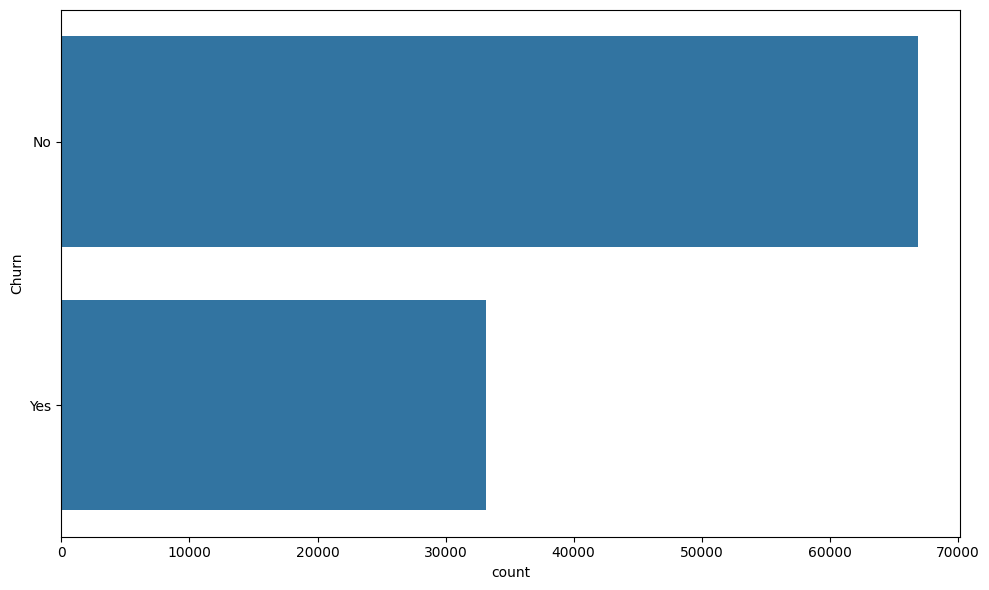

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(df['Churn'])
plt.tight_layout()
plt.show()

All inputs categoires(str) has multiple values and only output has two values

Checking outliers if usefull keep it

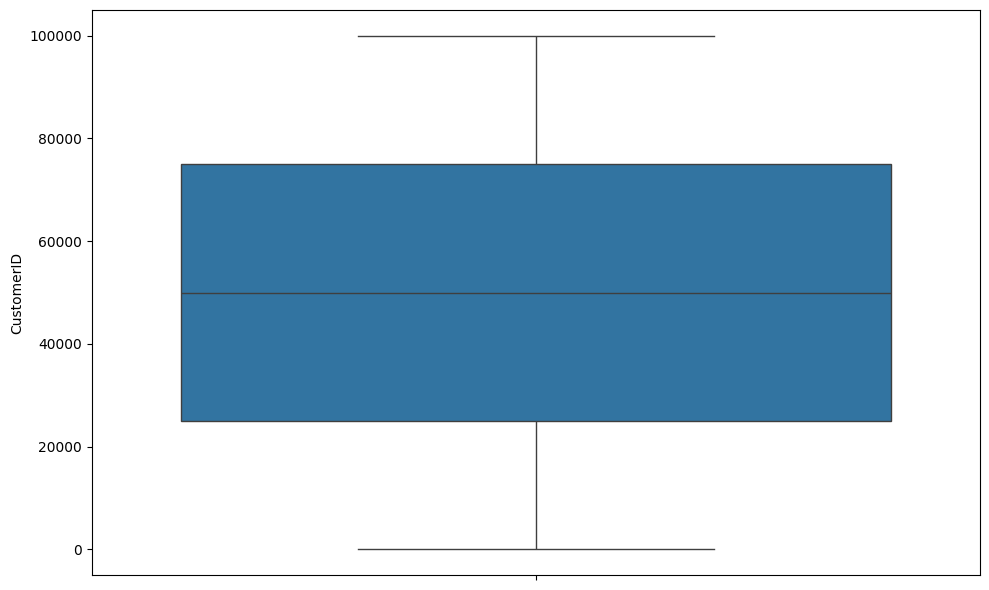

In [10]:
#Customer ID
plt.figure(figsize=(10,6))
sns.boxplot(df['CustomerID'])
plt.tight_layout()
plt.show()

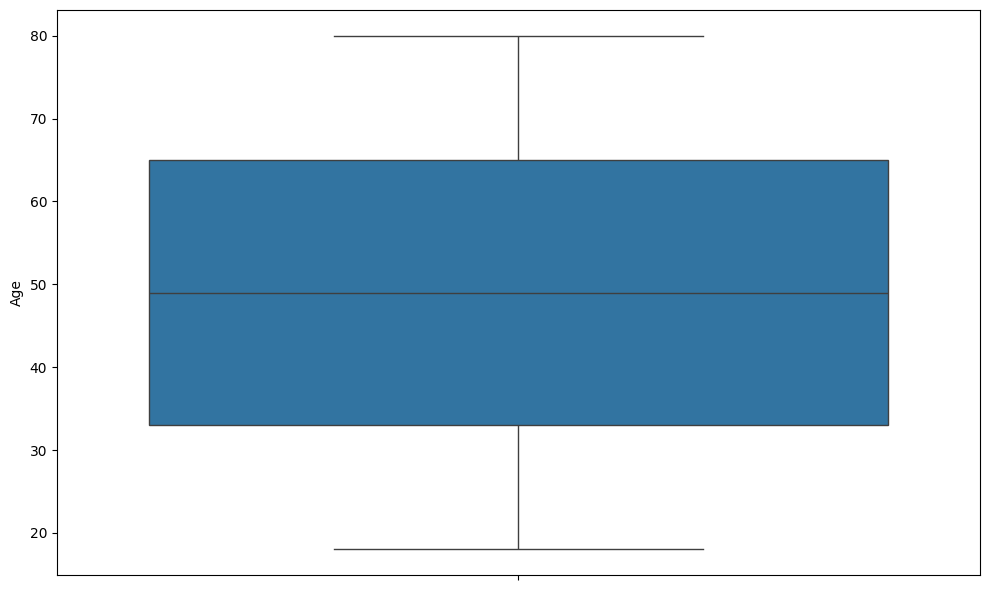

In [11]:
#Age
plt.figure(figsize=(10,6))
sns.boxplot(df['Age'])
plt.tight_layout()
plt.show()

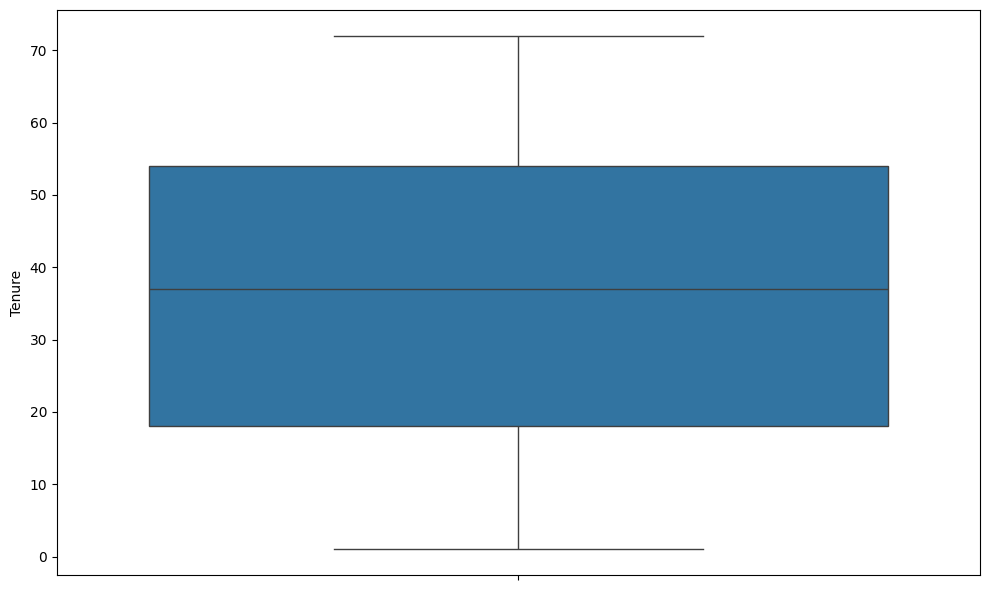

In [12]:
#Tenure
plt.figure(figsize=(10,6))
sns.boxplot(df['Tenure'])
plt.tight_layout()
plt.show()

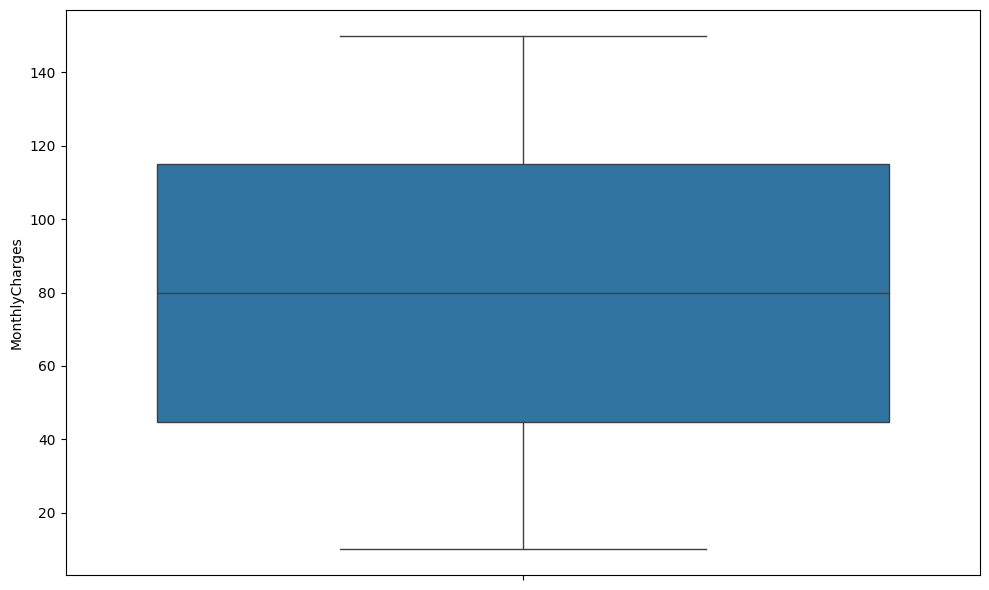

In [13]:
#MonthlyCharges
plt.figure(figsize=(10,6))
sns.boxplot(df['MonthlyCharges'])
plt.tight_layout()
plt.show()

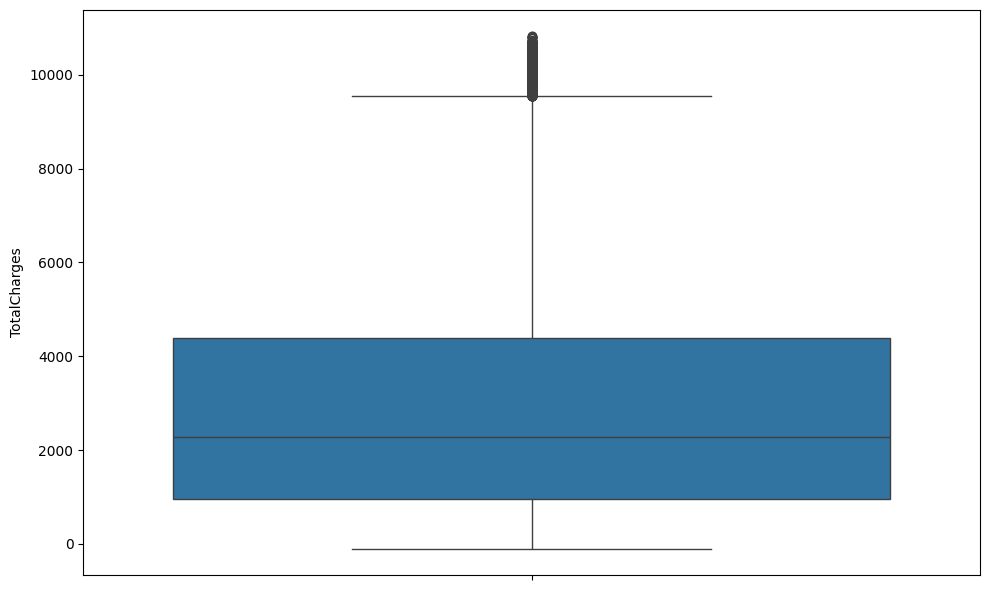

In [14]:
#TotalCharges
plt.figure(figsize=(10,6))
sns.boxplot(df['TotalCharges'])
plt.tight_layout()
plt.show()

In [15]:
(df['TotalCharges']>=10000).value_counts()

TotalCharges
False    99631
True       369
Name: count, dtype: int64

No issues in outliers and no null values here.

The numerical given data is clean our output and other data is in string format so we need to encode it

Preporcessing

Encoding

In [16]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [17]:
column_names = df.select_dtypes(include=['object', 'string']).columns.tolist()
column_names

['Gender', 'Contract', 'PaymentMethod', 'Churn']

To keep real data make copy of it

In [18]:
df_encoded=df.copy()
df_encoded.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


One-hot encoding for input

In [19]:
df_encoded = pd.get_dummies(data=df, columns=['Gender', 'Contract', 'PaymentMethod'], drop_first=True)
df_encoded.head()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,56,68,147.58,10052.03,No,False,False,False,True,False,False,False
1,2,69,32,22.54,686.78,No,True,False,False,False,False,False,True
2,3,46,10,52.47,537.88,No,False,False,True,False,False,True,False
3,4,32,22,109.67,2390.04,Yes,True,False,False,False,False,False,True
4,5,60,54,130.98,7081.28,No,False,False,False,False,True,False,False


Label encoding for output

In [20]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_encoded['Churn']=le.fit_transform(df_encoded['Churn'])
df_encoded.head()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,56,68,147.58,10052.03,0,False,False,False,True,False,False,False
1,2,69,32,22.54,686.78,0,True,False,False,False,False,False,True
2,3,46,10,52.47,537.88,0,False,False,True,False,False,True,False
3,4,32,22,109.67,2390.04,1,True,False,False,False,False,False,True
4,5,60,54,130.98,7081.28,0,False,False,False,False,True,False,False


Drop useless customer id column

In [21]:
df_encoded = df_encoded.drop('CustomerID', axis=1)
df_encoded.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,56,68,147.58,10052.03,0,False,False,False,True,False,False,False
1,69,32,22.54,686.78,0,True,False,False,False,False,False,True
2,46,10,52.47,537.88,0,False,False,True,False,False,True,False
3,32,22,109.67,2390.04,1,True,False,False,False,False,False,True
4,60,54,130.98,7081.28,0,False,False,False,False,True,False,False


Change all into int

In [22]:
df_encoded = df_encoded.astype(int)
df_encoded.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,56,68,147,10052,0,0,0,0,1,0,0,0
1,69,32,22,686,0,1,0,0,0,0,0,1
2,46,10,52,537,0,0,0,1,0,0,1,0
3,32,22,109,2390,1,1,0,0,0,0,0,1
4,60,54,130,7081,0,0,0,0,0,1,0,0


Lets check correlation between inputs and output using heatmap

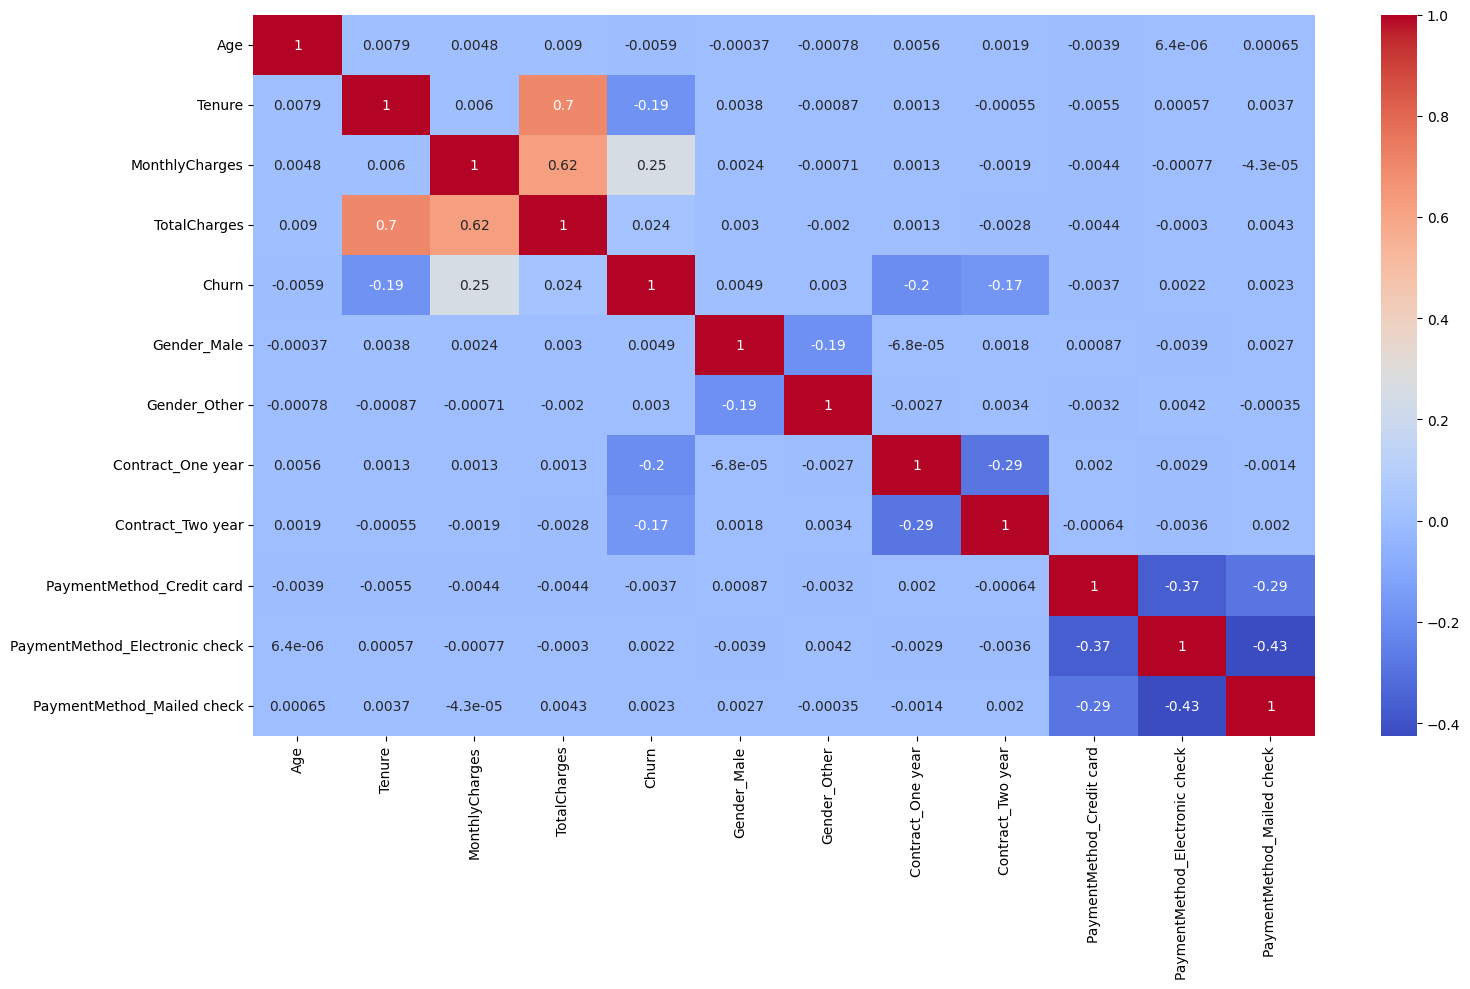

In [23]:
corr=df_encoded.corr()
plt.figure(figsize=(16,10))
sns.heatmap(corr,cmap='coolwarm',annot=True)
plt.tight_layout()
plt.show()

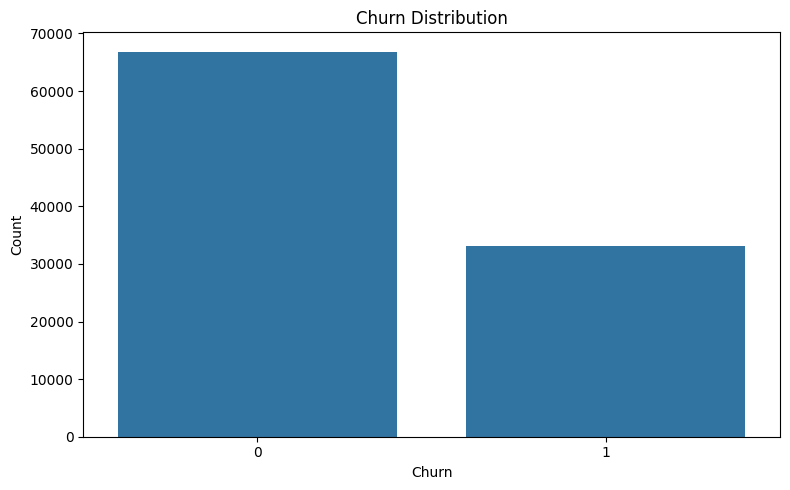

In [24]:
churn_counts = df_encoded['Churn'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=churn_counts.index, y=churn_counts.values)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [25]:
X=df_encoded.drop('Churn',axis=1)
y=df_encoded['Churn']
X.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,56,68,147,10052,0,0,0,1,0,0,0
1,69,32,22,686,1,0,0,0,0,0,1
2,46,10,52,537,0,0,1,0,0,1,0
3,32,22,109,2390,1,0,0,0,0,0,1
4,60,54,130,7081,0,0,0,0,1,0,0


Feature Scaling for Models

Split dataset first

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

Scaling

In [27]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
model_le=LogisticRegression()
model_le.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predict

In [29]:
y_pred=model_le.predict(X_test_scaled)
y_pred

array([0, 0, 1, ..., 0, 1, 0], shape=(20000,))

Accuracy,confusion matrix and classification Report

In [30]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_le = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy_le}")
confusion_matrix_le=confusion_matrix(y_test,y_pred)
print(confusion_matrix_le)
classification_report_le = classification_report(y_test, y_pred)
print(classification_report_le)

Accuracy Score: 0.72395
[[11366  1928]
 [ 3593  3113]]
              precision    recall  f1-score   support

           0       0.76      0.85      0.80     13294
           1       0.62      0.46      0.53      6706

    accuracy                           0.72     20000
   macro avg       0.69      0.66      0.67     20000
weighted avg       0.71      0.72      0.71     20000



KNN

In [31]:
from sklearn.neighbors import KNeighborsClassifier
model_kn=KNeighborsClassifier(n_neighbors=5)
model_kn.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Predict

In [32]:
y_pred_knn=model_kn.predict(X_test_scaled)
y_pred_knn

array([1, 0, 0, ..., 1, 1, 1], shape=(20000,))

Accuracy,confusion matrix and classification Report

In [33]:
accuracy_kn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy Score: {accuracy_kn}")
confusion_matrix_kn=confusion_matrix(y_test,y_pred_knn)
print(confusion_matrix_kn)
classification_report_kn = classification_report(y_test, y_pred_knn)
print(classification_report_kn)

Accuracy Score: 0.7089
[[10863  2431]
 [ 3391  3315]]
              precision    recall  f1-score   support

           0       0.76      0.82      0.79     13294
           1       0.58      0.49      0.53      6706

    accuracy                           0.71     20000
   macro avg       0.67      0.66      0.66     20000
weighted avg       0.70      0.71      0.70     20000



Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
model_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=30,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
model_tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Predict

In [35]:
y_pred_tree=model_tree.predict(X_test)
y_pred_tree

array([0, 0, 1, ..., 1, 1, 1], shape=(20000,))

Accuracy,confusion matrix and classification Report

In [36]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Accuracy Score: {accuracy_tree}")
confusion_matrix_tree=confusion_matrix(y_test,y_pred_tree)
print(confusion_matrix_tree)
classification_report_tree = classification_report(y_test, y_pred_tree)
print(classification_report_tree)

Accuracy Score: 0.74505
[[10703  2591]
 [ 2508  4198]]
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     13294
           1       0.62      0.63      0.62      6706

    accuracy                           0.75     20000
   macro avg       0.71      0.72      0.71     20000
weighted avg       0.75      0.75      0.75     20000



SVM

In [37]:
from sklearn.svm import LinearSVC
model_linear_svm = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
model_linear_svm.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

Predict

In [38]:
y_pred_svm=model_linear_svm.predict(X_test_scaled)
y_pred_svm

array([0, 0, 1, ..., 0, 1, 1], shape=(20000,))

Accuracy,confusion matrix and classification Report

In [39]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy Score: {accuracy_svm}")
confusion_matrix_svm=confusion_matrix(y_test,y_pred_svm)
print(confusion_matrix_svm)
classification_report_svm = classification_report(y_test, y_pred_svm)
print(classification_report_svm)

Accuracy Score: 0.68815
[[9062 4232]
 [2005 4701]]
              precision    recall  f1-score   support

           0       0.82      0.68      0.74     13294
           1       0.53      0.70      0.60      6706

    accuracy                           0.69     20000
   macro avg       0.67      0.69      0.67     20000
weighted avg       0.72      0.69      0.70     20000



Random Forerst

In [40]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=30,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

Predict

In [41]:
y_pred_rf = model_rf.predict(X_test)

Accuracy,confusion matrix and classification Report

In [42]:
print("--- RANDOM FOREST RESULTS ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf)}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- RANDOM FOREST RESULTS ---
Accuracy Score: 0.7416

Confusion Matrix:
[[10554  2740]
 [ 2428  4278]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80     13294
           1       0.61      0.64      0.62      6706

    accuracy                           0.74     20000
   macro avg       0.71      0.72      0.71     20000
weighted avg       0.74      0.74      0.74     20000



In [43]:
import joblib
joblib.dump(model_tree, 'decision_tree_model.pkl')
feature_list = list(X_train.columns)
joblib.dump(feature_list, 'features_list.pkl')

['features_list.pkl']